In [1]:
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, ToolMessage
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
import re
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3

from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition
import requests
from pydantic import BaseModel, Field
from typing import Literal, Optional, Union, List
from langchain_google_community import CalendarToolkit
from langchain_google_community.calendar.create_event import CalendarCreateEvent

from datetime import datetime

from langchain_google_community import GmailToolkit
import json
import operator
import os
from groq import Groq



c:\Work_Projects\Agentic_AI_11_04_2026\MyChatBot\Meeting_Summarizer\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from google_auth_oauthlib.flow import InstalledAppFlow
from google.oauth2.credentials import Credentials
import os

SCOPES = [
    "https://www.googleapis.com/auth/gmail.send",
    "https://www.googleapis.com/auth/calendar",
]

creds = None

# Load existing token
if os.path.exists("token.json"):
    creds = Credentials.from_authorized_user_file("token.json", SCOPES)

# If not valid → login again
if not creds or not creds.valid:
    flow = InstalledAppFlow.from_client_secrets_file(
        "credentials.json",
        SCOPES
    )
    creds = flow.run_local_server(port=0)

    # Save token
    with open("token.json", "w") as token:
        token.write(creds.to_json())

Please visit this URL to authorize this application: https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=509758089312-pnrh4mghsvo6j90j81709mnmvvd1sfn0.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A64943%2F&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fgmail.send+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcalendar&state=sEmB2d787e4JyewFil1ishAHEfydPf&code_challenge=8HFRsAYNcX5UHQJmkgMv5RUjtS58P41Ln_GSNuj8iFw&code_challenge_method=S256&access_type=offline


In [3]:
Cal_toolkit = CalendarToolkit(credentials=creds)
Cal_tools = Cal_toolkit.get_tools()

GM_toolkit = GmailToolkit(credentials=creds)
GM_tools = GM_toolkit.get_tools()
Cal_tools, GM_tools

([CalendarCreateEvent(api_resource=<googleapiclient.discovery.Resource object at 0x000001EE158774D0>),
  CalendarSearchEvents(api_resource=<googleapiclient.discovery.Resource object at 0x000001EE158774D0>),
  CalendarUpdateEvent(api_resource=<googleapiclient.discovery.Resource object at 0x000001EE158774D0>),
  GetCalendarsInfo(api_resource=<googleapiclient.discovery.Resource object at 0x000001EE158774D0>),
  CalendarMoveEvent(api_resource=<googleapiclient.discovery.Resource object at 0x000001EE158774D0>),
  CalendarDeleteEvent(api_resource=<googleapiclient.discovery.Resource object at 0x000001EE158774D0>),
  GetCurrentDatetime(api_resource=<googleapiclient.discovery.Resource object at 0x000001EE158774D0>)],
 [GmailCreateDraft(api_resource=<googleapiclient.discovery.Resource object at 0x000001EE158E2AD0>),
  GmailSendMessage(api_resource=<googleapiclient.discovery.Resource object at 0x000001EE158E2AD0>),
  GmailSearch(api_resource=<googleapiclient.discovery.Resource object at 0x000001EE

In [4]:
tools= Cal_tools+GM_tools
tools

[CalendarCreateEvent(api_resource=<googleapiclient.discovery.Resource object at 0x000001EE158774D0>),
 CalendarSearchEvents(api_resource=<googleapiclient.discovery.Resource object at 0x000001EE158774D0>),
 CalendarUpdateEvent(api_resource=<googleapiclient.discovery.Resource object at 0x000001EE158774D0>),
 GetCalendarsInfo(api_resource=<googleapiclient.discovery.Resource object at 0x000001EE158774D0>),
 CalendarMoveEvent(api_resource=<googleapiclient.discovery.Resource object at 0x000001EE158774D0>),
 CalendarDeleteEvent(api_resource=<googleapiclient.discovery.Resource object at 0x000001EE158774D0>),
 GetCurrentDatetime(api_resource=<googleapiclient.discovery.Resource object at 0x000001EE158774D0>),
 GmailCreateDraft(api_resource=<googleapiclient.discovery.Resource object at 0x000001EE158E2AD0>),
 GmailSendMessage(api_resource=<googleapiclient.discovery.Resource object at 0x000001EE158E2AD0>),
 GmailSearch(api_resource=<googleapiclient.discovery.Resource object at 0x000001EE158E2AD0>),

In [5]:
from dotenv import load_dotenv
load_dotenv()
llm_plain = ChatGroq(
    model="qwen/qwen3-32b",
)

In [6]:
class ActionItem(BaseModel):
    title: str = Field(description="title of the task")
    task: str = Field(description="a detailed task description")
    assignee: Optional[str] = Field(default=None, description="Specific person responsible for the task; avoid vague terms like 'team' unless explicitly stated")
    deadline: Optional[str] = Field(default=None, description="Deadline or time reference for the task or event time etc., if any")
    type: str = Field(description="Type of action: email | meeting | reminder | general")
    priority: Literal["low", "medium", "high"] = Field(default="medium", description="Priority level of the task")


class ExtractedData(BaseModel):
    summary: str = Field(
        description=(
        "Write a structured meeting summary with the following sections:\n"
        "- Topics Discussed\n"
        "- Key Decisions\n"
        "- Outcomes / Next Steps\n\n"
        "Keep it concise, factual, and avoid adding information not present in the meeting."
        )
    )

    participants: List[str] = Field(
        description=(
        "List of participant names exactly as mentioned in the meeting. "
        "Use full names if available. Avoid abbreviations unless explicitly used."
        )
    )
    
    action_items: List[ActionItem] = Field(
        default_factory=list,
        description = "Extract concise action items. Merge tasks per person. No vague or duplicate items. Return [] if none."    
        )
    

class GraphState(dict):
    transcript: Optional[str]
    audio_file: Optional[str]
    transcript_format: str
    summary: Optional[str]
    action_items: Optional[List[dict]]
    participants: Optional[List[str]]
    
    messages: Annotated[list[BaseMessage], add_messages]
    final_summary: str

In [7]:
# Tool-enabled LLM 
llm_with_tools = llm_plain.bind_tools(tools)

# plain LLM with str output
structured_llm = llm_plain.with_structured_output(ExtractedData)

In [8]:
def transcribe(state):
    filename= state["audio_file"]
    client = Groq(api_key=os.getenv("GROQ_API_KEY"))
    with open(filename, "rb") as file:
        transcription = client.audio.transcriptions.create(
            file=(filename, file.read()),
            model="whisper-large-v3",
            temperature=0,
            response_format="verbose_json",
        )
    return {"transcript": transcription.text}

In [9]:
template = ChatPromptTemplate(
    [
        ("system", """You are an AI agent with access to tools.

GENERAL RULES:
- Do NOT include any <think> tags
- Do NOT show reasoning
- Be concise and action-oriented
- Use tools whenever required to complete tasks
- Do NOT assume missing information

WORKFLOW:
1. Carefully analyze the provided action items
2. For each action item, decide required actions
3. Execute actions using tools step-by-step

PARTICIPANT HANDLING:
- assignee_email is already provided when available
- Do NOT attempt to resolve emails again

TIME HANDLING:
- If any action involves date/time → MUST call get_current_datetime FIRST
- Normalize relative times (e.g., "tomorrow", "next week") before using tools

ACTION RULES:
For each action item:
- If assignee exists AND email is resolved → send email using Gmail tool
- If type == "meeting" → create calendar event
- If deadline exists → create calendar reminder
- If multiple conditions apply → perform ALL relevant actions

FAILURE HANDLING:
- If required information is missing → skip that action
- Do NOT guess or hallucinate missing fields
- Continue processing remaining action items

OUTPUT:
- Only return tool outputs or final concise confirmations
"""),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

In [10]:
def get_email_from_db(name: str):
    db = {
        "rohit jangir": "rohit@example.com",
        "ankit sharma": "ankit@example.com",
    }
    return db.get(name.lower().strip(), "22B1502@iitb.ac.in")

In [11]:
def extract_node(state: GraphState):
    result: ExtractedData = structured_llm.invoke(state["transcript"])
    action_items= [item.model_dump() for item in result.action_items]

    for item in action_items:
        assignee = item.get("assignee")
        if assignee:
            email = get_email_from_db(assignee) if assignee else None
            item["assignee_email"] = email
    
    re= {
        "summary": result.summary,
        "action_items": action_items,
        "participants": result.participants
    }
    prompt = f"""
        Process the following action items using tools as needed.
        {json.dumps(re["action_items"], indent=2)}
        """
    re["messages"]= [HumanMessage(content=prompt)]
    return re

In [12]:
def tool_agent_node(state: GraphState):
    prompt_value = template.invoke({
        "messages": state["messages"]
    })

    response = llm_with_tools.invoke(
         prompt_value
    )
    
    return {
        "messages": [response]
        }


In [13]:
tool_node = ToolNode(tools, handle_tool_errors=True)

In [14]:
def remove_think(text):
    return re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL).strip()
def final_node(state: GraphState):
    
    summary=state["summary"]
    action_items= state["action_items"]
    prompt= f" Given the following meeting summary and action items, generate a detailed report that includes the main points and the action items in a clear format.\n\nSummary:\n{summary}\n\nAction Items:\n{json.dumps(action_items, indent=2)}\n\nFinal Summary:"
    final_summary = remove_think(llm_plain.invoke(prompt).content)
    return {
        "final_summary": final_summary,
    }

In [15]:
def router(state: GraphState):
    if state["transcript_format"] == "audio":
        return "audio"
    else:
        return "text"

In [16]:
builder = StateGraph(GraphState)


builder.add_node("transcribe", transcribe)
builder.add_node("extract", extract_node)
builder.add_node("agent", tool_agent_node)
builder.add_node("tools", tool_node)
builder.add_node("final", final_node)


builder.add_conditional_edges(
    START,
    router,
    {
        "audio": "transcribe",
        "text": "extract"
    }
)
builder.add_edge("transcribe", "extract")

builder.add_edge("extract", "agent")
builder.add_conditional_edges(
    "agent",
    tools_condition, 
    {
        "tools": "tools",
        "__end__": "final" 
    }
)

builder.add_edge("tools", "agent")

builder.add_edge("final", END)

graph = builder.compile()

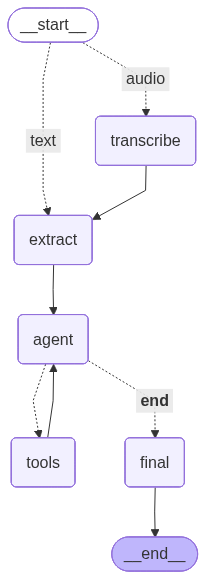

In [17]:
graph

In [18]:


result = graph.invoke({
    "audio_file": "Test_meeting.mp3",
    "transcript_format": "audio"
})

In [19]:
result

{'transcript': " Hi, this is Eric Johnson. It's February 18th, 2021, and this is the engineering key review at GitLab. So I've got number four in the agenda, which is a proposal to break up this meeting into four department key reviews. So currently this is engineering, development, quality, security, and UX, infrastructure and support do their own key reviews already. I have the reasons why, increased visibility, able to go deeper, increased the objectivity with which my reports can manage their groups, allow me more time to focus on new markets, and allow me to shift into more of a question asker mode than generating content and answering questions in these meetings. And, but to avoid adding three net new meetings to stakeholders calendars, I propose we do a sort of two month rotation. So month one, development quality go, month two, security and UX would go. How do people feel about that proposal? I think in the group conversations it's working really well um so I'm I'm supportive a

In [20]:
print(result["final_summary"])

# Meeting Report: Engineering Key Review and Metrics Optimization  

## **Overview**  
This report outlines the key discussions, decisions, and action items from the recent meeting focused on optimizing engineering processes and metrics. The primary topics included restructuring departmental reviews, refining R&D metrics, addressing Postgres replication challenges, and improving defect tracking metrics.  

---

## **Key Discussions**  
### 1. **Departmental Key Review Rotation**  
- **Proposal**: Split engineering key reviews into departmental meetings (e.g., Development/Quality and Security/UX) on a two-month rotation.  
- **Purpose**: Streamline reviews, improve focus, and ensure department-specific challenges are addressed effectively.  

### 2. **R&D MR Rate Metrics**  
- **Debate**: Transitioned from tracking R&D merge request (MR) rates to measuring the percentage of MRs contributed by the community.  
- **Goal**: Avoid duplication and better reflect community collaboration.  

#